# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.parallel
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F


from torchsummary import summary
from torchmetrics import MeanAbsolutePercentageError, MeanSquaredError

import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils

from IPython.display import clear_output
from sklearn.model_selection import train_test_split

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set the random seed

In [3]:
random_seed = 42
random.seed(random_seed)
torch.manual_seed(random_seed)

# Global Variables

In [4]:
WINDOW = 5
HORIZON = 1
TRAIN_SPLIT = 0.8
VAL_SPLIT = 0.5

# Load the data

In [5]:
AMD = pd.read_csv('C:/Users/kanek/University/Coding-Webe-Kuliah/Tugas/Semester-4/Deep_Learning/UAS/LSTM/Dataset_A/AMD.csv', parse_dates=True)

AMD['Date'] = pd.to_datetime(AMD['Date'])
AMD.set_index('Date', inplace=True)

## Filter the data to only include the "close" price

In [6]:
data = AMD['Close']

# EDA

In [7]:
data.head()

Date
1980-03-17    3.145833
1980-03-18    3.031250
1980-03-19    3.041667
1980-03-20    3.010417
1980-03-21    2.916667
Name: Close, dtype: float64

In [8]:
data.describe()

count    10098.000000
mean        11.210802
std          8.283645
min          1.620000
25%          4.937500
50%          9.062500
75%         14.707500
max         58.900002
Name: Close, dtype: float64

## Plot the data

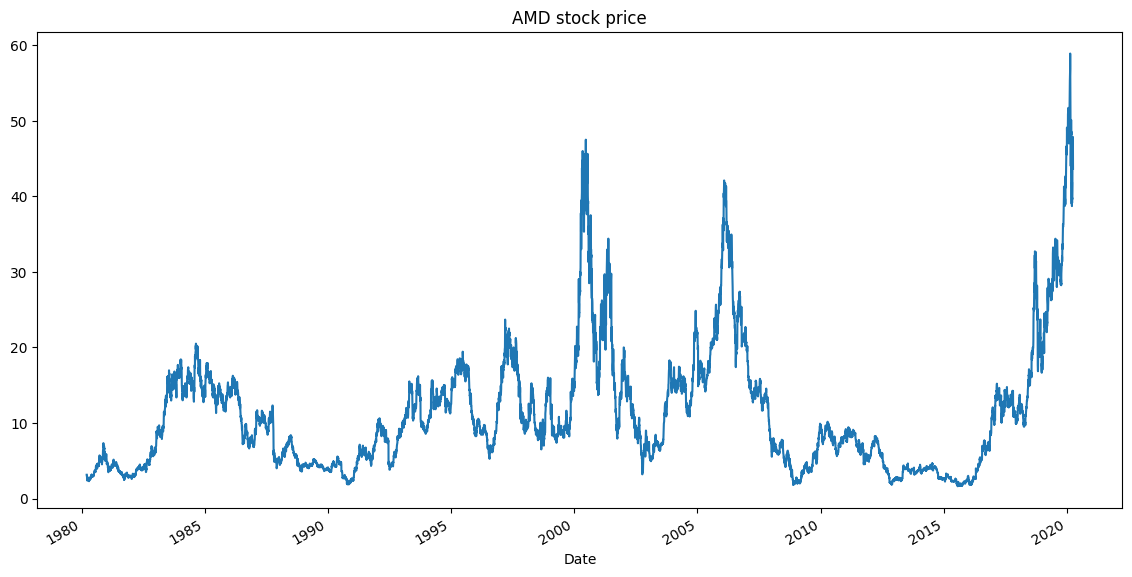

In [9]:
plt.figure(figsize=(14, 7))
data.plot()
plt.title('AMD stock price')
plt.show()

# Preprocessing

## MinMaxScaling

In [10]:
class MinMaxScaler():
    def __init__(self):
        self.min = None
        self.max = None

    def fit(self, data):
        self.min = data.min()
        self.max = data.max()

    def transform(self, data):
        return (data - self.min) / (self.max - self.min)
    
    def fit_transform(self, data):
        self.fit(data)
        return self.transform(data)

    def inverse_transform(self, data):
        return data * (self.max - self.min) + self.min
    
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

## Create Time Series Instances

In [11]:
def create_instances(data, window : int = 1, future : int = 1):
    X, y = [], []
    for i in range(len(data)-window-future):
        feature = data[i : i+window]
        # target = data[i+future+1 : i+window+future+1]
        target = data[i+window+future]
        X.append(feature)
        y.append(target)
    return X, y

In [12]:
X, y = create_instances(scaled_data, window=WINDOW, future=HORIZON)

C:\Users\kanek\AppData\Local\Temp\ipykernel_21836\3521555928.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  target = data[i+window+future]


## Split the data into training, validation, and testing sets

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=TRAIN_SPLIT, shuffle=False, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, train_size=VAL_SPLIT, shuffle=False, random_state=42)

## Create the data loaders

In [14]:
train_ds = torch.utils.data.TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).float())
val_ds = torch.utils.data.TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).float())
test_ds = torch.utils.data.TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).float())

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

C:\Users\kanek\AppData\Local\Temp\ipykernel_21836\2147813206.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  train_ds = torch.utils.data.TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).float())
C:\Users\kanek\AppData\Local\Temp\ipykernel_21836\2147813206.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  val_ds = torch.utils.data.TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).float())
C:\Users\kanek\AppData\Local\Temp\ipykernel_21836\2147813206.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be trea

# Model Architecture

In [15]:
class Model(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(Model, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.linear = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.linear(out)
        return out

# Loss Function

In [16]:
loss_fn = nn.L1Loss() # MAE
loss_fn.to(device)
metrics = [MeanAbsolutePercentageError(), MeanSquaredError()]
metrics = [metric.to(device) for metric in metrics]

# Training Loop

In [17]:
def train_loop(model, dataloader, loss_fn, optimizer, metrics):
    model.train()
    running_loss = 0
    running_metrics = [0] * len(metrics)
    
    tqdm_dataloader = tqdm(dataloader)
    
    for i, (X, y) in enumerate(tqdm_dataloader):
        X, y = X.to(device), y.to(device)
        
        optimizer.zero_grad()
        y_pred = model(X)
        
        loss = loss_fn(y_pred.squeeze(), y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        for i, metric in enumerate(metrics):
            running_metrics[i] += metric(y_pred.squeeze(), y).item()
    
    return running_loss / len(dataloader), [metric / len(dataloader) for metric in running_metrics]

# Validation Loop

In [18]:
def val_loop(model, dataloader, loss_fn, metrics):
    model.eval()
    running_loss = 0
    running_metrics = [0] * len(metrics)
    
    with torch.no_grad():
        for X, y in tqdm(dataloader):
            X, y = X.to(device), y.to(device)

            y_pred = model(X)

            loss = loss_fn(y_pred.squeeze(), y)
            
            running_loss += loss.item()
            for i, metric in enumerate(metrics):
                running_metrics[i] += metric(y_pred.squeeze(), y).item()
    
    return running_loss / len(dataloader), [metric / len(dataloader) for metric in running_metrics]

# Base Model

In [19]:
baseModel = Model(WINDOW, 50, HORIZON)

In [20]:
print(baseModel)

Model(
  (lstm): LSTM(5, 50, batch_first=True)
  (linear): Linear(in_features=50, out_features=1, bias=True)
)


## Compile the model

In [21]:
baseModel.to(device)
base_optimizer = optim.Adam(baseModel.parameters(), lr=0.001)

## Train the model

In [22]:
epochs = 50

train_losses = []
val_losses = []
train_metrics = []
val_metrics = []

best_val_loss = np.inf
no_improvement = 0

for epoch in range(epochs):
    print(f'Epoch {epoch+1}/{epochs}')
    
    train_loss, train_metric = train_loop(baseModel, train_loader, loss_fn, base_optimizer, metrics)
    val_loss, val_metric = val_loop(baseModel, val_loader, loss_fn, metrics)
    
    clear_output()
    
    print(f'Training Loss: {train_loss:.4f}')
    print(f'Validation Loss: {val_loss:.4f}')
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_metrics.append(train_metric)
    val_metrics.append(val_metric)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print('Saving best model')
        torch.save(baseModel.state_dict(), 'best_model.pth')
    else :
        print('No improvement')
        no_improvement += 1
        
    if no_improvement > 5:
        print('Early stopping')
        break

Training Loss: 0.0089
Validation Loss: 0.0041
No improvement
Early stopping


## Evaluate the model

### Training Loss vs Validation Loss

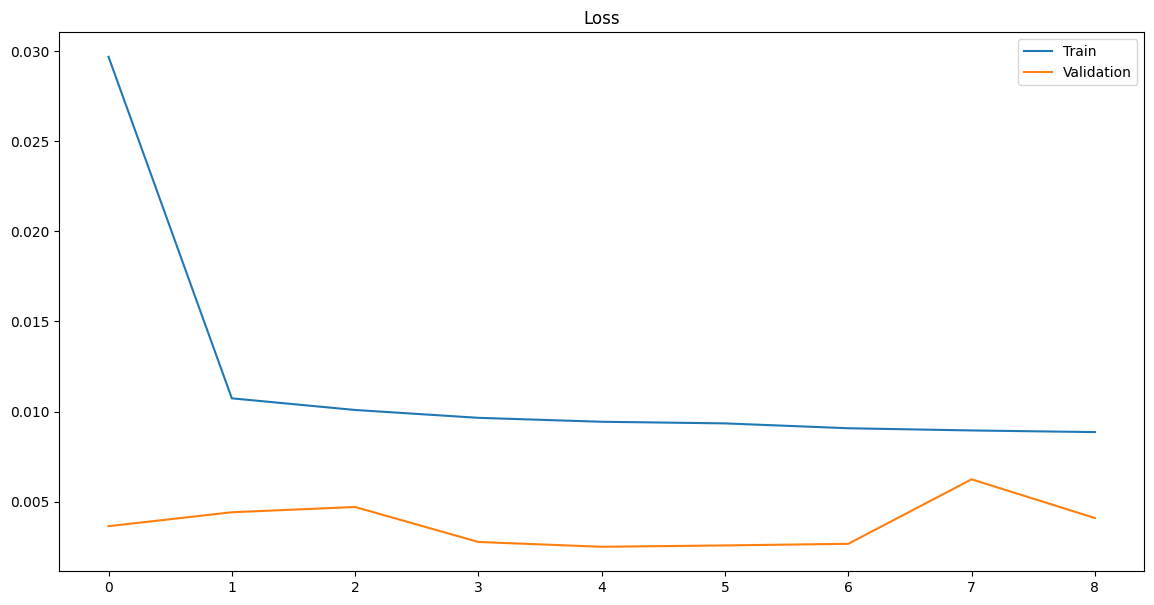

In [23]:
plt.figure(figsize=(14, 7))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.title('Loss')
plt.legend()
plt.show()

### Training Statistics

In [24]:
print('Best validation loss:', scaler.inverse_transform(best_val_loss))
print('Last validation loss:', scaler.inverse_transform(val_loss))
print("Last validation MAPE:", val_metric[0] *100)
print("Last validation MSE:", scaler.inverse_transform(val_metric[1]))

Best validation loss: 1.762494791243776
Last validation loss: 1.8539076494142734
Last validation MAPE: 89.58756939973682
Last validation MSE: 1.621283538917466


## Analyzation

From the Plot and the statistics we can conclude that the model is overfitting the data and  from MAPE score of 89% (predicted deviationof 89%)  the model is overestimating some part of the data seen from the explosion of MAPE even when the MAE is only 1.8. We will try to improve the model by simplifying the model (Lowering neuron in LSTM layer) and adjusting learning rate using learning rate scheduler.

# Tuned Model

In [25]:
tunedModel = Model(WINDOW, 25, HORIZON)
tunedModel.to(device)

tuned_optimizer = optim.Adam(tunedModel.parameters(), lr=0.0001)
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(tuned_optimizer, patience=2, verbose=True)

c:\Users\kanek\miniconda3\envs\PyTorch-DL\Lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


## Training the model

In [26]:
epochs = 100

train_losses = []
val_losses = []
train_metrics = []
val_metrics = []

best_val_loss = np.inf
no_improvement = 0

for epoch in range(epochs):
    print(f'Epoch {epoch+1}/{epochs}')
    
    train_loss, train_metric = train_loop(tunedModel, train_loader, loss_fn, tuned_optimizer, metrics)
    val_loss, val_metric = val_loop(tunedModel, val_loader, loss_fn, metrics)
    
    clear_output()
    
    print(f'Training Loss: {train_loss:.4f}')
    print(f'Validation Loss: {val_loss:.4f}')
    
    before_lr = tuned_optimizer.param_groups[0]['lr']
    lr_scheduler.step(val_loss)
    after_lr = tuned_optimizer.param_groups[0]['lr']
    
    print(f'Learning rate: {before_lr} -> {after_lr}')
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_metrics.append(train_metric)
    val_metrics.append(val_metric)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print('Saving best model')
        torch.save(tunedModel.state_dict(), 'best_model.pth')
    else :
        print('No improvement')
        no_improvement += 1
        
    if no_improvement > 5:
        print('Early stopping')
        break

Training Loss: 0.0104
Validation Loss: 0.0047
Learning rate: 1e-05 -> 1e-05
No improvement
Early stopping


## Evaluate the model

### Training Loss vs Validation Loss

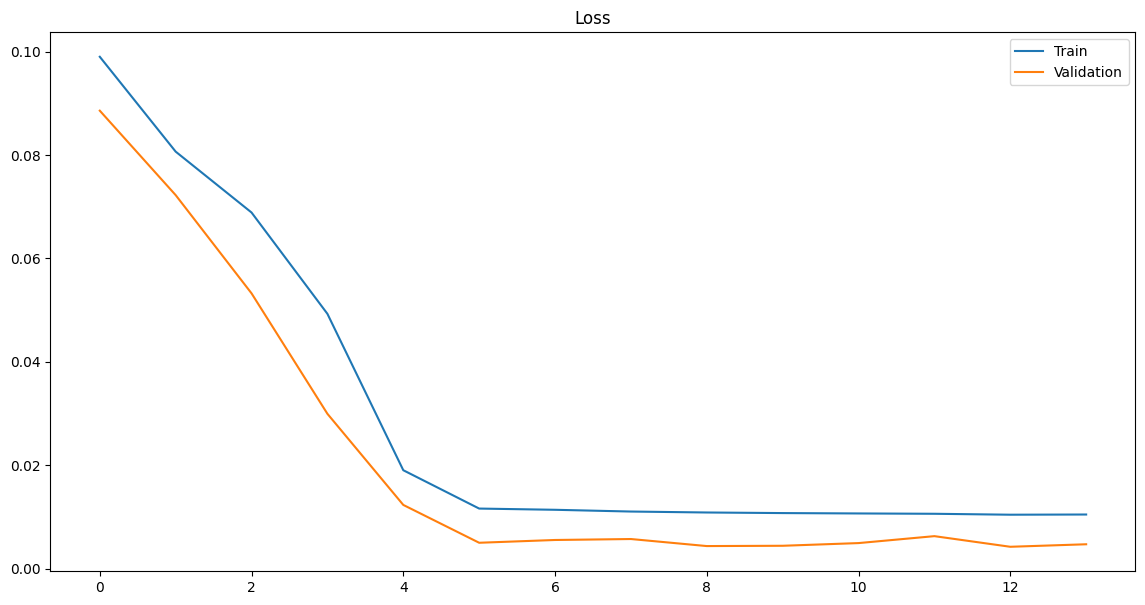

In [27]:
plt.figure(figsize=(14, 7))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.title('Loss')
plt.legend()
plt.show()

The model is reaching convergence thus it's no longer overfitting the data.

### Training Statistics

In [28]:
print('Best validation loss:', scaler.inverse_transform(best_val_loss))
print('Last validation loss:', scaler.inverse_transform(val_loss))
print("Last validation MAPE:", val_metric[0] * 100)
print("Last validation MSE:", scaler.inverse_transform(val_metric[1]))

Best validation loss: 1.8608051034913475
Last validation loss: 1.888596347809068
Last validation MAPE: 625.710673967842
Last validation MSE: 1.6226418312966386


## Analyzation

The Model is performing well on the validation set with a average 2.6% predicted deviation. We will now evaluate the model on the test set.

# Test Set Evaluation

In [29]:
eval_loss, eval_metric = val_loop(tunedModel, test_loader, loss_fn, metrics)

print('Test loss:', scaler.inverse_transform(eval_loss))
print('Test MAPE:', eval_metric[0] * 100)
print('Test MSE:', scaler.inverse_transform(eval_metric[1]))

100%|██████████| 32/32 [00:00<00:00, 255.34it/s]

Test loss: 2.6266910397724748
Test MAPE: 6.499582540709525
Test MSE: 1.665540613942638


## Visualize the prediction

100%|██████████| 32/32 [00:00<00:00, 873.79it/s]


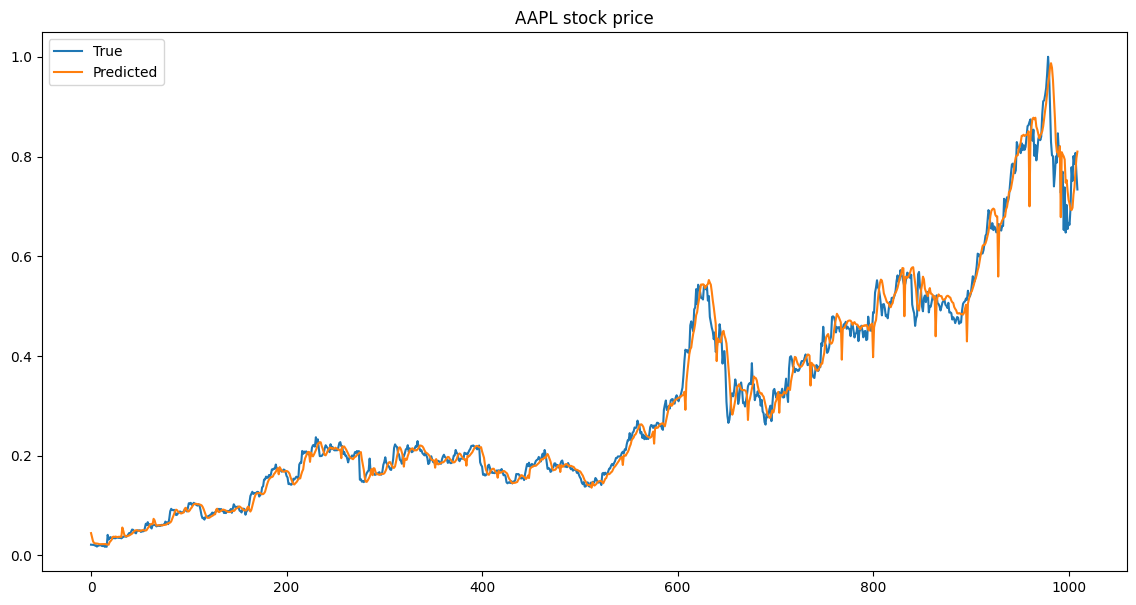

In [30]:
def predict(model, dataloader):
    model.eval()
    predictions = []
    
    with torch.no_grad():
        for X, y in tqdm(dataloader):
            X = X.to(device)
            y_pred = model(X)
            predictions.append(y_pred.squeeze().cpu().numpy())
    
    return np.concatenate(predictions)

predictions = predict(tunedModel, test_loader)
y_true = np.array(y_test)

plt.figure(figsize=(14, 7))
plt.plot(y_true, label='True')
plt.plot(predictions, label='Predicted')
plt.title('AAPL stock price')
plt.legend()
plt.show()

# Conclusion

The model is performing well, with it's average test deviation of 6.5% or 2.6 USD. But when plotted agains the actual data there's time when the model severely underpredict the price and sometime the model can also lag behiind. Thus the model can be improved by adding more data or be used as a reference point. But it's enough to use as a reference point for trading.